In [2]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)
import warnings
warnings.filterwarnings("ignore")


In [3]:
df = pd.read_csv("hf://datasets/zefang-liu/phishing-email-dataset/Phishing_Email.csv")

df.head()


,Unnamed: 0,Email Text,Email Type
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,1,the other side of * galicismos * * galicismo *...,Safe Email
2,2,re : equistar deal tickets are you still avail...,Safe Email
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email


In [4]:
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18650 entries, 0 to 18649
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  18650 non-null  int64 
 1   Email Text  18634 non-null  object
 2   Email Type  18650 non-null  object
dtypes: int64(1), object(2)
memory usage: 437.2+ KB


Unnamed: 0     0
Email Text    16
Email Type     0
dtype: int64

In [5]:
df.dropna(inplace=True)


In [6]:
df = df.rename(columns={
    'Email Text': 'email_text',
    'Email Type': 'label'
})

df['label'].value_counts()


label
Safe Email        11322
Phishing Email     7312
Name: count, dtype: int64

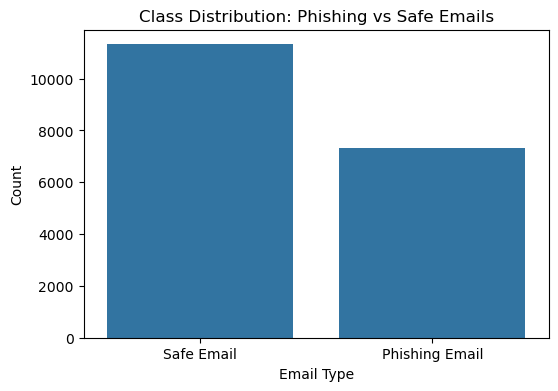

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)
plt.title("Class Distribution: Phishing vs Safe Emails")
plt.xlabel("Email Type")
plt.ylabel("Count")
plt.show()


In [8]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text)
    return text


In [9]:
df['clean_email'] = df['email_text'].apply(clean_text)


In [10]:

df['label_binary'] = df['label'].map({
    'Phishing Email': 1,
    'Safe Email': 0
})


In [11]:
X = df['clean_email']
y = df['label_binary']


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [12]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    stop_words='english'
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


In [13]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf_model.fit(X_train_tfidf, y_train)


RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)

In [14]:
y_pred = rf_model.predict(X_test_tfidf)
y_prob = rf_model.predict_proba(X_test_tfidf)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.9600214649852428

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.95      0.97      2265
           1       0.93      0.97      0.95      1462

    accuracy                           0.96      3727
   macro avg       0.96      0.96      0.96      3727
weighted avg       0.96      0.96      0.96      3727



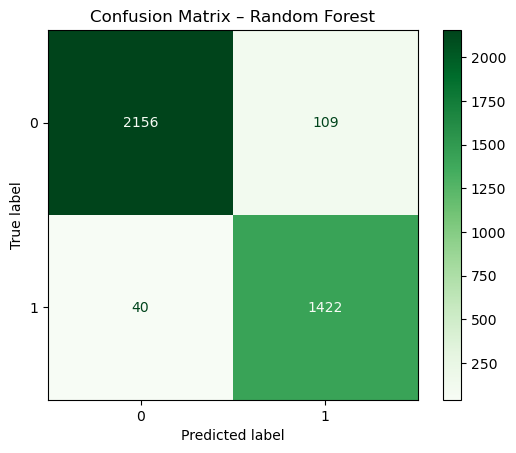

In [15]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Greens')
plt.title("Confusion Matrix – Random Forest")
plt.show()


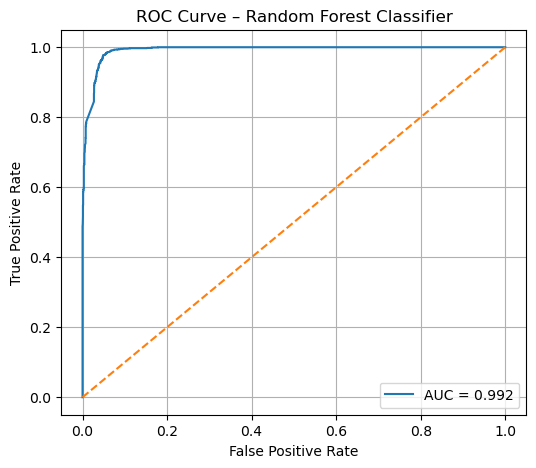

In [16]:
from sklearn.metrics import roc_curve, auc

# Predict probabilities for the positive class (Phishing = 1)
y_prob = rf_model.predict_proba(X_test_tfidf)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Random Forest Classifier")
plt.legend()
plt.grid(True)
plt.show()


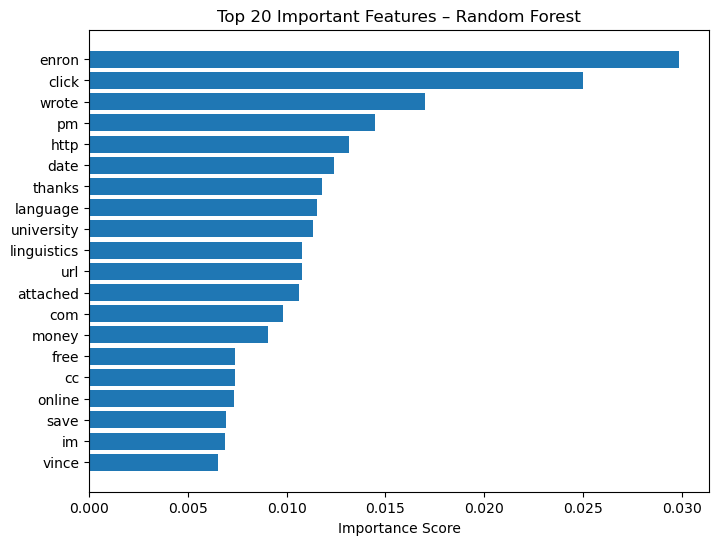

In [17]:
feature_importance = rf_model.feature_importances_
indices = np.argsort(feature_importance)[-20:]

plt.figure(figsize=(8,6))
plt.barh(range(len(indices)), feature_importance[indices])
plt.yticks(range(len(indices)), [tfidf.get_feature_names_out()[i] for i in indices])
plt.title("Top 20 Important Features – Random Forest")
plt.xlabel("Importance Score")
plt.show()


In [21]:

y_train_pred_rf = rf_model.predict(X_train_tfidf)

print("Random Forest - TRAINING DATA\n")
print(classification_report(y_train, y_train_pred_rf))

print("\nRandom Forest - TESTING DATA\n")
print(classification_report(y_test, y_pred))


Random Forest - TRAINING DATA

              precision    recall  f1-score   support

           0       1.00      0.98      0.99      9057
           1       0.97      1.00      0.99      5850

    accuracy                           0.99     14907
   macro avg       0.99      0.99      0.99     14907
weighted avg       0.99      0.99      0.99     14907


Random Forest - TESTING DATA

              precision    recall  f1-score   support

           0       0.98      0.95      0.97      2265
           1       0.93      0.97      0.95      1462

    accuracy                           0.96      3727
   macro avg       0.96      0.96      0.96      3727
weighted avg       0.96      0.96      0.96      3727



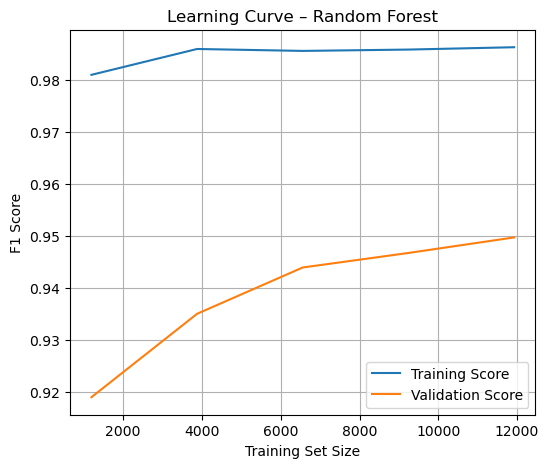

In [22]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(model, X, y, title):
    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X,
        y,
        cv=5,
        scoring='f1',
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5)
    )

    train_mean = np.mean(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)

    plt.figure(figsize=(6,5))
    plt.plot(train_sizes, train_mean, label="Training Score")
    plt.plot(train_sizes, val_mean, label="Validation Score")
    plt.xlabel("Training Set Size")
    plt.ylabel("F1 Score")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()
plot_learning_curve(
    RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight='balanced'
    ),
    X_train_tfidf,
    y_train,
    "Learning Curve – Random Forest"
)


In [24]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced']
}
rf = RandomForestClassifier(random_state=42)
grid_rf = GridSearchCV(rf, param_grid_rf, cv=3, scoring='f1', n_jobs=-1)
grid_rf.fit(X_train_tfidf, y_train)
print(f"Best Parameters for Random Forest: {grid_rf.best_params_}")
best_rf_model = grid_rf.best_estimator_

Best Parameters for Random Forest: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


In [25]:
y_pred_rf = best_rf_model.predict(X_test_tfidf)
print("Classification Report for Random Forest:")
print(classification_report(y_test, y_pred_rf))

Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.98      0.95      0.97      2265
           1       0.93      0.97      0.95      1462

    accuracy                           0.96      3727
   macro avg       0.96      0.96      0.96      3727
weighted avg       0.96      0.96      0.96      3727



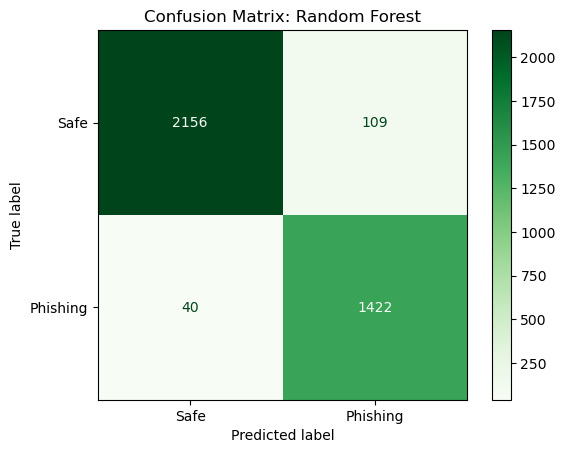

In [26]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Safe', 'Phishing'])
disp_rf.plot(cmap='Greens')
plt.title('Confusion Matrix: Random Forest')
plt.show()

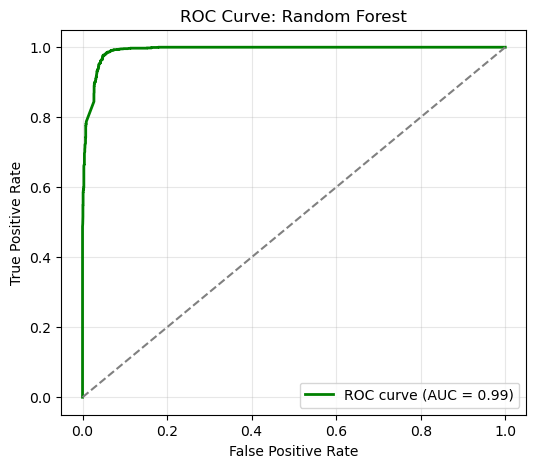

In [27]:
y_prob_rf = best_rf_model.predict_proba(X_test_tfidf)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='green', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Random Forest')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

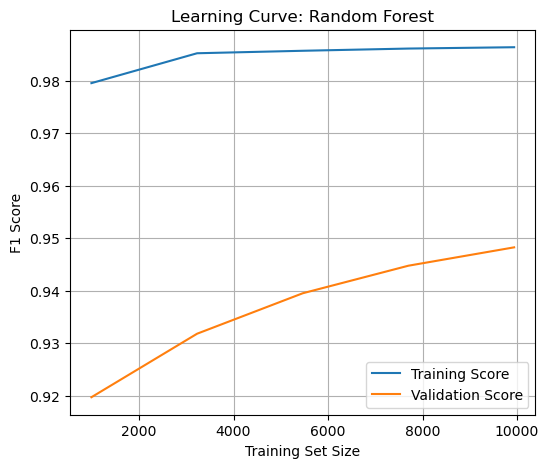

In [28]:
train_sizes, train_scores, val_scores = learning_curve(
    best_rf_model, X_train_tfidf, y_train, cv=3, scoring='f1', n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5)
)

plt.figure(figsize=(6, 5))
plt.plot(train_sizes, np.mean(train_scores, axis=1), label="Training Score")
plt.plot(train_sizes, np.mean(val_scores, axis=1), label="Validation Score")
plt.xlabel("Training Set Size")
plt.ylabel("F1 Score")
plt.title("Learning Curve: Random Forest")
plt.legend()
plt.grid(True)
plt.show()

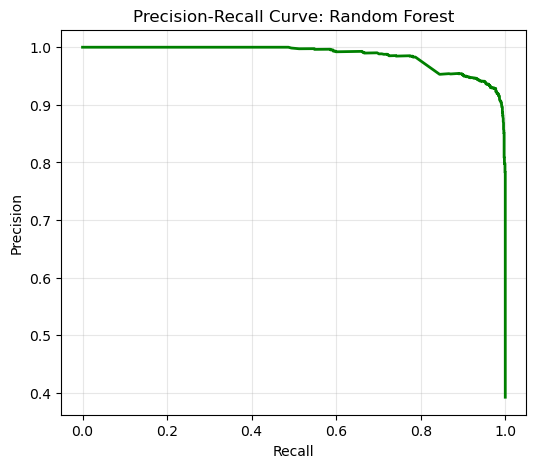

In [30]:
from sklearn.metrics import precision_recall_curve
precision, recall, _ = precision_recall_curve(y_test, y_prob_rf)
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, color='green', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve: Random Forest')
plt.grid(alpha=0.3)
plt.show()

In [32]:
from sklearn.model_selection import cross_val_score, KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_rf = cross_val_score(best_rf_model, X_train_tfidf, y_train, cv=kf, scoring='accuracy')

print("Random Forest K-Fold Scores:", cv_scores_rf)
print(f"Mean Accuracy: {cv_scores_rf.mean():.4f}")
print(f"Standard Deviation: {cv_scores_rf.std():.4f}")

Random Forest K-Fold Scores: [0.95942321 0.96143528 0.96041597 0.95907414 0.9617578 ]
Mean Accuracy: 0.9604
Standard Deviation: 0.0011


In [33]:
import joblib
joblib.dump(best_rf, "random_forest_phishing_model.pkl")


['random_forest_phishing_model.pkl']